# 02 — Data Exploration

Explore the local VQA v2 + COCO 2014 data:
- Dataset sizes and splits
- Question-type distribution
- Answer distribution (top-K)
- Image sample grid
- Vocabulary analysis

In [1]:
import os, sys
# Set working directory to project root
os.chdir('..')
sys.path.insert(0, '.')

In [2]:
import json
from pathlib import Path
from collections import Counter

import yaml
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

with open('configs/config.yaml') as f:
    cfg = yaml.safe_load(f)

print('Config loaded.')
print(f"Train annotations: {cfg['data']['annotations_train']}")
print(f"Val annotations:   {cfg['data']['annotations_val']}")

Config loaded.
Train annotations: data/raw/annotations/v2_mscoco_train2014_annotations.json
Val annotations:   data/raw/annotations/v2_mscoco_val2014_annotations.json


## 1. Load JSON data

In [3]:
ann_train = json.loads(Path(cfg['data']['annotations_train']).read_text())
ann_val   = json.loads(Path(cfg['data']['annotations_val']).read_text())
q_train   = json.loads(Path(cfg['data']['questions_train']).read_text())
q_val     = json.loads(Path(cfg['data']['questions_val']).read_text())

print(f"Train annotations : {len(ann_train['annotations']):,}")
print(f"Train questions   : {len(q_train['questions']):,}")
print(f"Val   annotations : {len(ann_val['annotations']):,}")
print(f"Val   questions   : {len(q_val['questions']):,}")

Train annotations : 443,757
Train questions   : 443,757
Val   annotations : 214,354
Val   questions   : 214,354


## 2. Question-type distribution

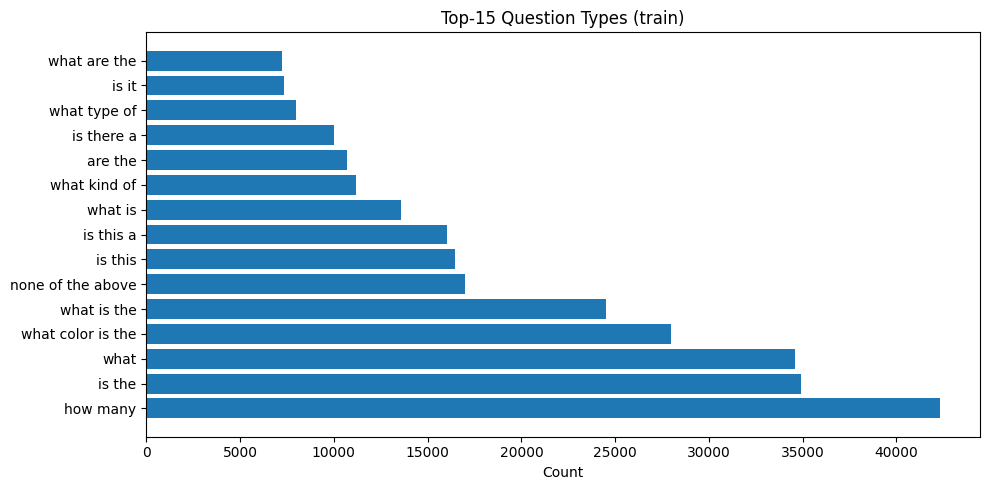

In [4]:
q_types = Counter(a['question_type'] for a in ann_train['annotations'])
top_types = q_types.most_common(15)

fig, ax = plt.subplots(figsize=(10, 5))
labels, counts = zip(*top_types)
ax.barh(labels, counts)
ax.set_xlabel('Count')
ax.set_title('Top-15 Question Types (train)')
plt.tight_layout()
Path('outputs/eda_plots').mkdir(parents=True, exist_ok=True)
plt.savefig('outputs/eda_plots/question_types.png', dpi=150)
plt.show()

## 3. Answer distribution (top-50)

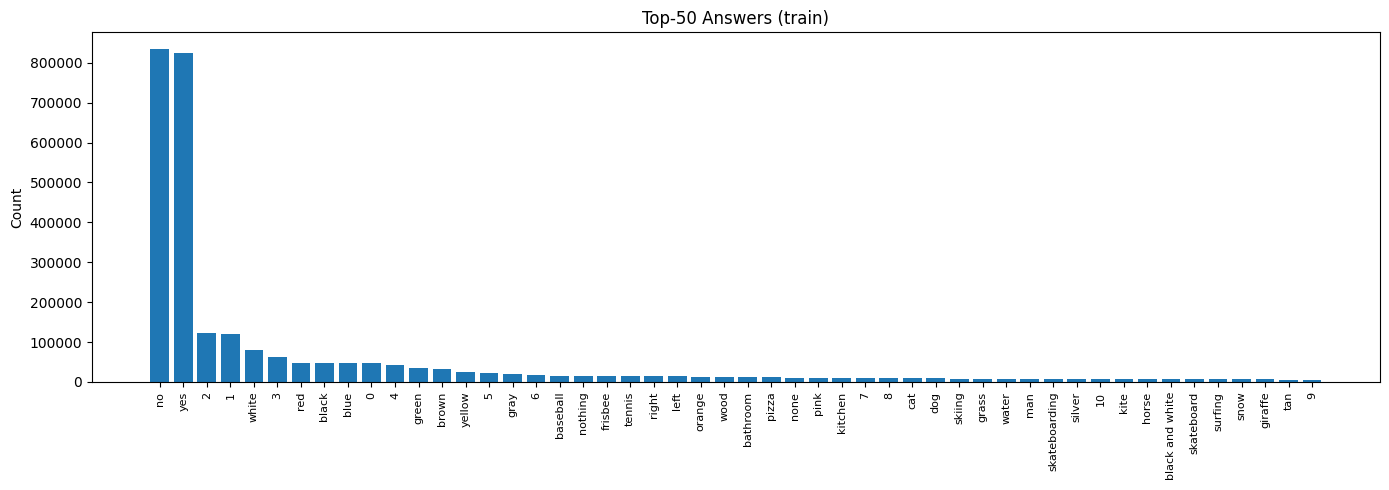

In [5]:
all_answers = Counter()
for ann in ann_train['annotations']:
    for a in ann['answers']:
        all_answers[a['answer']] += 1

top_answers = all_answers.most_common(50)
labels, counts = zip(*top_answers)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(labels)), counts)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_ylabel('Count')
ax.set_title('Top-50 Answers (train)')
plt.tight_layout()
plt.savefig('outputs/eda_plots/answer_distribution.png', dpi=150)
plt.show()

## 4. Sample image grid

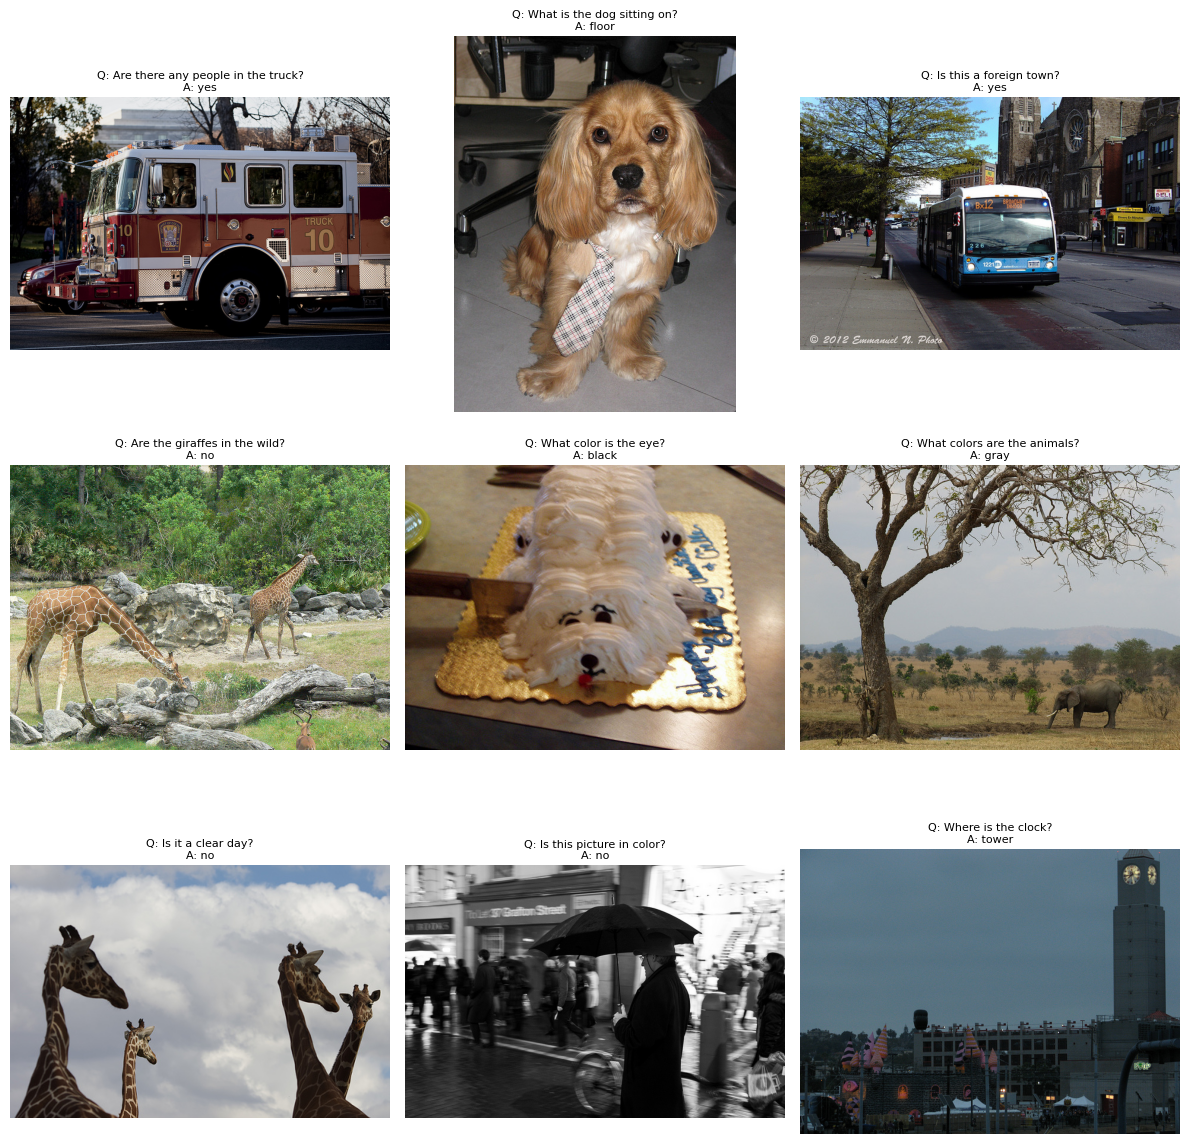

In [6]:
import random
from src.data.answer_vocab import AnswerVocab

images_dir = Path(cfg['data']['images_train'])
samples = random.sample(q_train['questions'], 9)
ann_lookup = {a['question_id']: a for a in ann_train['annotations']}

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for ax, q in zip(axes.flatten(), samples):
    img_path = images_dir / f"COCO_train2014_{q['image_id']:012d}.jpg"
    img = Image.open(img_path).convert('RGB')
    ann = ann_lookup.get(q['question_id'], {})
    top_ans = ann.get('multiple_choice_answer', '?')
    ax.imshow(img)
    ax.set_title(f"Q: {q['question']}\nA: {top_ans}", fontsize=8, wrap=True)
    ax.axis('off')
plt.tight_layout()
plt.savefig('outputs/eda_plots/sample_images.png', dpi=150)
plt.show()

## 5. Vocabulary analysis (requires build_vocab.py to have been run)

In [7]:
vocab_path = Path(cfg['paths']['vocab_path'])
if vocab_path.exists():
    vocab = AnswerVocab.load(vocab_path)
    print(f"Vocabulary size: {len(vocab):,} answers")
    print(f"First 20: {vocab._idx2ans[2:22]}")
else:
    print('Vocab not found — run: python scripts/build_vocab.py')

Vocabulary size: 15,256 answers
First 20: ['no', 'yes', '2', '1', 'white', '3', 'red', 'black', 'blue', '0', '4', 'green', 'brown', 'yellow', '5', 'gray', '6', 'baseball', 'nothing', 'frisbee']
